In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
subgraphllm = ChatGroq(
    model="openai/gpt-oss-120b"
)
parentllm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [5]:
class ParentState(TypedDict):

    question: str
    answer_eng: str
    answer_hin: str

In [6]:
def translate_text(state: ParentState):

    prompt = f"""
                Translate the following text to Hindi.
                Keep it natural and clear. Do not add extra content.

                Text:
                {state["answer_eng"]}
                """.strip()
    
    translated_text = subgraphllm.invoke(prompt).content

    return {'answer_hin': translated_text}

In [7]:
subgraph_builder = StateGraph(ParentState)
subgraph_builder.add_node('translate_text', translate_text)
subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)
subgraph = subgraph_builder.compile()

In [8]:
def generate_answer(state: ParentState):

    answer = parentllm.invoke(f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}").content
    return {'answer_eng': answer}

In [10]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", subgraph)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)
parent_workflow = parent_builder.compile()

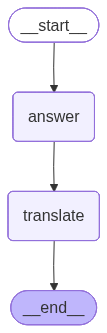

In [11]:
parent_workflow

In [12]:
parent_workflow.invoke({'question': 'What is quantum physics'})

{'question': 'What is quantum physics',
 'answer_eng': '**Quantum physics** (also called quantum mechanics or quantum theory) is the branch of physics that describes how matter and energy behave at the smallest scales—typically at the level of atoms, electrons, photons, and other sub‑atomic particles.  \n\n---\n\n### Why a new theory was needed\nClassical physics (Newtonian mechanics, electromagnetism, thermodynamics) works extremely well for everyday objects, but it fails to explain several phenomena observed in the early 20th\u202fcentury, such as:\n\n| Phenomenon | Classical expectation | Quantum explanation |\n|------------|----------------------|----------------------|\n| Black‑body radiation | Predicted infinite energy at short wavelengths (the “ultraviolet catastrophe”) | Energy is emitted in discrete packets (quanta) → Planck’s law |\n| Photoelectric effect | Light of any intensity should eject electrons | Light consists of photons; only photons with enough energy (frequency) c